In [11]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from autoencoder import ConvAutoencoder, NonLinearAutoencoder
from solver import dev_train_vali_all_epochs_conv, test_conv
from rf_computation import compute_rf_for_single_model

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

from autoencoder import NonLinearAutoencoder
from solver import *
from model_utils import *

In [12]:
print(torch.cuda.is_available())
device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

True


In [13]:
save_path = os.path.expanduser('~/paper_cifar_models/cnn/pca-init-cifar/')
print('save_path:', save_path)
if not os.path.exists(save_path):
    os.makedirs(save_path)

save_path: /home/david/paper_cifar_models/cnn/pca-init-cifar/


In [14]:
# CIFAR10 normalization (RGB channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR10 datasets
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split training set into train/validation
train_size = int(len(cifar_train) * 0.8)  # 40,000 samples
validation_size = len(cifar_train) - train_size  # 10,000 samples
cifar_train, cifar_val = torch.utils.data.random_split(cifar_train, [train_size, validation_size])

# Create data loaders
batch_size = 128
train_loader = DataLoader(cifar_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(cifar_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(cifar_test, batch_size=batch_size, shuffle=False, num_workers=6)

Files already downloaded and verified
Files already downloaded and verified


In [19]:
def initialize_bottleneck_with_pca(train_loader, model):
    """Extract conv features and do PCA on them"""
    model.eval()
    conv_features = []
    
    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(train_loader):
            if batch_idx >= 100:  # Use subset for efficiency
                break
            
            # Move data to same device as model
            data = data.to(next(model.parameters()).device)
            
            # Forward through conv layers only (before linear)
            x = data
            for layer in model.encoder[:-1]:  # All layers except the final Linear
                x = layer(x)
            
            conv_features.append(x.cpu().numpy())
    
    conv_features = np.concatenate(conv_features, axis=0)  # Shape: (N, 1024)
    
    # PCA on 1024-dimensional conv features
    pca = PCA(n_components=128)
    pca.fit(conv_features)
    
    # Initialize the linear layer weights - convert to same device and dtype
    with torch.no_grad():
        device = next(model.parameters()).device
        dtype = next(model.parameters()).dtype
        
        pca_weights = torch.from_numpy(pca.components_).to(device=device, dtype=dtype)
        model.encoder[-1].weight.copy_(pca_weights)
        model.encoder[-1].bias.zero_()
    
    return model

def initialize_sae_with_pca():
    """Initialize the ConvAutoencoder with PCA weights"""
    sae_model = ConvAutoencoder(latent_dim=128).to(device)  # Move to device first
    
    # Initialize bottleneck with PCA
    sae_model = initialize_bottleneck_with_pca(train_loader, sae_model)
    
    # Define optimizer
    sae_optimizer = torch.optim.SGD(sae_model.parameters(), lr=0.1, momentum=0.9)
    
    return sae_model, sae_optimizer

In [20]:
for i in range(0, 1):
    save_path = os.path.join(os.path.expanduser('~'), 'cifar_models/sae-latent-pca-init', str(i))
    os.makedirs(save_path, exist_ok=True)

    sae_model_pca_init, sae_optimizer = initialize_sae_with_pca()

    train_loss, vali_loss = train_vali_all_epochs_conv(
                                                sae_model_pca_init,
                                                train_loader,
                                                validation_loader,
                                                sae_optimizer,
                                                60,
                                                device,
                                                save_path + '/',
                                                )

    np.save(os.path.join(save_path, 'train_loss.npy'), train_loss)
    np.save(os.path.join(save_path, 'vali_loss.npy'), vali_loss)

Train Epoch: 0 [19968/40000 (100%)]	Loss: 0.014756: 100%|██████████| 313/313 [00:04<00:00, 62.62it/s]

====> Epoch: 0 Average loss: 1.0003


====> Test set loss: 3072.0855
Weights saved.


Train Epoch: 1 [19968/40000 (100%)]	Loss: 0.013805: 100%|██████████| 313/313 [00:06<00:00, 50.04it/s]

====> Epoch: 1 Average loss: 0.9971


...

Train Epoch: 58 [19968/40000 (100%)]	Loss: 0.002404: 100%|██████████| 313/313 [00:06<00:00, 49.56it/s]

====> Epoch: 58 Average loss: 0.1688


====> Test set loss: 517.4655
Weights saved.


Train Epoch: 59 [19968/40000 (100%)]	Loss: 0.002978: 100%|██████████| 313/313 [00:05<00:00, 58.37it/s]


====> Epoch: 59 Average loss: 0.1686
====> Test set loss: 514.5859
Weights saved.


In [ ]:
train_losses = []
vali_losses = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'vali_loss.npy'))
    train_losses.append(train_loss_i)
    vali_losses.append(vali_loss_i)

train_losses = np.stack(train_losses)
vali_losses = np.stack(vali_losses)

train_loss_mean = train_losses.mean(axis=0)
train_loss_std = train_losses.std(axis=0)
vali_loss_mean = vali_losses.mean(axis=0)
vali_loss_std = vali_losses.std(axis=0)

In [ ]:
train_losses_pca = []
vali_losses_pca = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/paper_cifar_models/cnn/pca-init-cifar/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/paper_cifar_models/cnn/pca-init-cifar/', str(i), 'vali_loss.npy'))
    train_losses_pca.append(train_loss_i)
    vali_losses_pca.append(vali_loss_i)

train_losses_pca = np.stack(train_losses_pca)
vali_losses_pca = np.stack(vali_losses_pca)

train_loss_mean_pca = train_losses_pca.mean(axis=0)
train_loss_std_pca = train_losses_pca.std(axis=0)
vali_loss_mean_pca = vali_losses_pca.mean(axis=0)
vali_loss_std_pca = vali_losses_pca.std(axis=0)

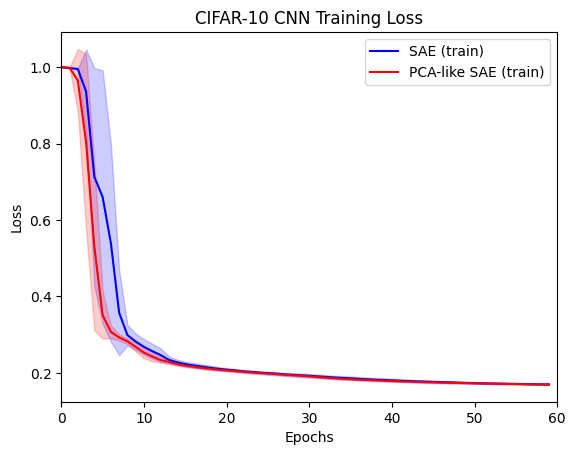

In [ ]:
plt.plot(train_loss_mean, label='SAE (train)', color='blue')
plt.fill_between(np.arange(len(train_loss_mean)), train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2, color='blue')
plt.plot(train_loss_mean_pca, label='PCA-like SAE (train)', color='red')
plt.fill_between(np.arange(len(train_loss_mean_pca)), train_loss_mean_pca - train_loss_std_pca, train_loss_mean_pca + train_loss_std_pca, alpha=0.2, color='red')
plt.legend()
plt.title('CIFAR-10 CNN Training Loss')
plt.xlabel('Epochs')
plt.xlim(0, 60)
plt.ylabel('Loss')
plt.show()

In [52]:
from rf_computation import compute_final_rfs

dae_rfs = compute_final_rfs(model_type='sae-latent-pca-init', dataset='cifar', size_ls=None, num_models=1, num_epochs=60, base_path=os.path.expanduser('~/'))

Loading existing results from Results/cifar_sae-latent-pca-init_final_rfs.npy


In [53]:
sae_rfs = np.load('Results/cifar_sae_rfs.npy')
sae_rfs.shape

(10, 128, 3, 32, 32)

In [56]:
dae_rfs.shape

(1, 128, 3, 32, 32)

In [57]:
# dae_rfs = np.load('Results/cifar_sae-latent-pca-init_final_rfs.npy')
dae_rfs = np.repeat(dae_rfs, 10, axis=0)
dae_rfs = np.repeat(dae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
print(dae_rfs.shape)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

(10, 60, 128, 3, 32, 32)


In [60]:
sae_rfs = np.repeat(sae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [58]:
dae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [59]:
sae_rfs.shape

(10, 128, 3, 32, 32)

In [68]:
np.save('Results/cifar_sae_rfs.npy', sae_rfs)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

In [62]:
from power_spectra import compute_power_spectra

sae_power_spectra, dae_power_spectra = compute_power_spectra(save_path_sae=None, save_path_dae=None, sae_rfs=sae_rfs, dae_rfs=dae_rfs, num_models=10, epoch=0)

100%|██████████| 10/10 [00:00<00:00, 21.09it/s]


In [66]:
from power_spectra import plot_power_spectra

plot_power_spectra(model_type='cnn', sae_power_spectra=sae_power_spectra, dae_power_spectra=dae_power_spectra)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


NameError: name 'fig' is not defined

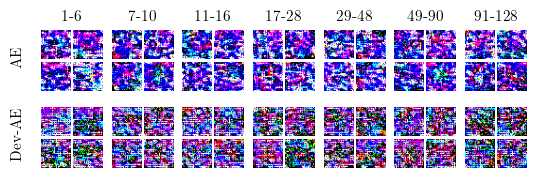

In [69]:
from plot_example_rfs import plot_example_rfs

fig = plt.figure(figsize=(6.26, 1.9))
ax = fig.add_subplot(111)
plot_example_rfs(ax, dataset='cifar', epoch_idx=59)
plt.close(fig)